In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# 如果需要显示中文，可取消下面两行注释（Windows/本地环境可能需要）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# ========== 1. 加载数据 ==========
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  #此处因为load_diabetes里包含了data.data，data.feature_names，data.target
print("数据形状：", df.shape)
print("\n前5行：")
print(df.head())
print("\n描述性统计：")
print(df.describe())

数据形状： (442, 11)

前5行：
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

描述性统计：
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e

In [4]:
# ========== 2. 查看各特征与目标的相关性 ==========
print("\n各特征与 target 的相关系数：")
print(df.corr()['target'].sort_values(ascending=False))


各特征与 target 的相关系数：
target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


In [10]:
# ========== 3. 准备特征 X 和目标 y ==========
X = df.drop('target', axis=1)#.drop删除target，axis=1按照列删，=0按行删
y = df['target']

In [11]:
# ========== 4. 划分训练/测试集 ==========
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
# ========== 5. 标准化特征 ==========
# 线性回归本身不要求标准化，但标准化后系数具有可比性，也有利于某些优化算法
#标准化的基本思想是：把每个特征变成“均值约等于 0，标准差约等于 1”。
scaler = StandardScaler()#创建一个“标准化工具”，把它命名为 scaler
X_train_scaled = scaler.fit_transform(X_train)   # fit 学习训练集的标准化规则，transform按照这个规则转换训练集
X_test_scaled = scaler.transform(X_test)         # 测试集只 transform，按照训练集的方式标准化，否则导致数据泄露

In [13]:
# ========== 6. 训练多元线性回归模型 ==========
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("\n模型截距：", round(model.intercept_, 2))
coef_df = pd.DataFrame({
    '特征': data.feature_names,
    '标准化系数': model.coef_  #标准化系数，是模型在“特征已经标准化”的情况下学习得到的系数
})
print("\n各特征系数（标准化后）：")
print(coef_df)


模型截距： 153.74

各特征系数（标准化后）：
    特征      标准化系数
0  age   1.753758
1  sex -11.511809
2  bmi  25.607121
3   bp  16.828872
4   s1 -44.448856
5   s2  24.640954
6   s3   7.676978
7   s4  13.138784
8   s5  35.161195
9   s6   2.351364


In [14]:
# ========== 7. 预测与评估 ==========
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
def evaluate(y_true, y_pred, name):
    print(f"\n{name}评估：")
    print(f"  MAE:  {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"  MSE:  {mean_squared_error(y_true, y_pred):.2f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"  R²:   {r2_score(y_true, y_pred):.4f}")
evaluate(y_train, y_train_pred, "训练集")
evaluate(y_test, y_test_pred, "测试集")


训练集评估：
  MAE:  43.48
  MSE:  2868.55
  RMSE: 53.56
  R²:   0.5279

测试集评估：
  MAE:  42.79
  MSE:  2900.19
  RMSE: 53.85
  R²:   0.4526


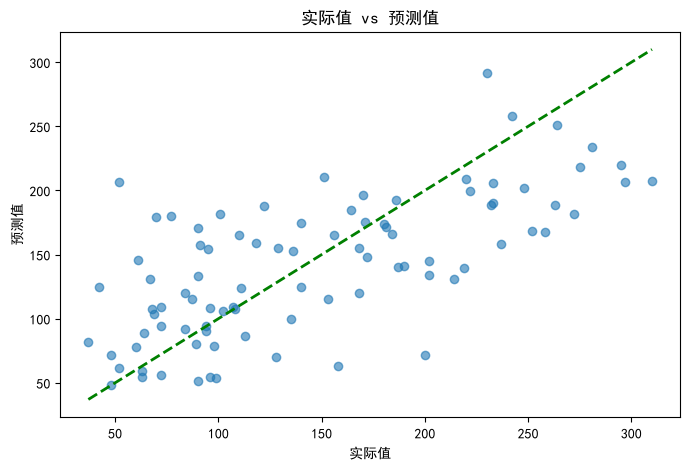

In [19]:
# ========== 8. 实际值 vs 预测值散点图 ==========
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g--', linewidth=2)
plt.xlabel('实际值')
plt.ylabel('预测值')
plt.title('实际值 vs 预测值')
plt.show()

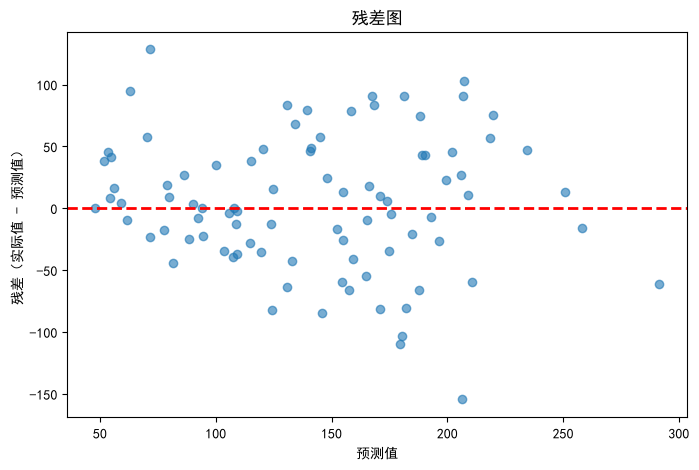

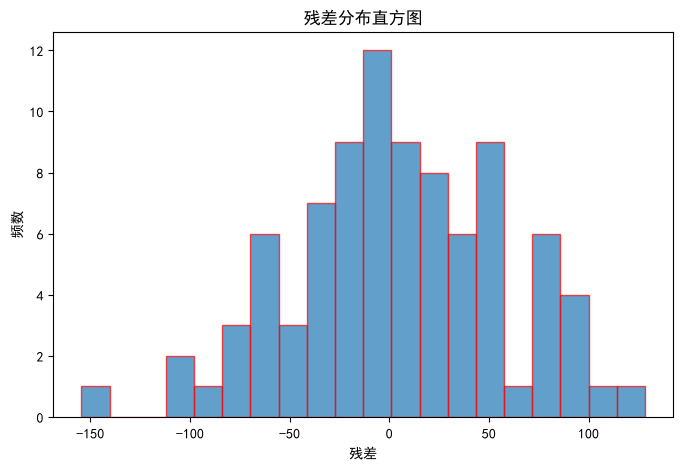

In [30]:
# ========== 9. 残差诊断 ==========
residuals = y_test - y_test_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('预测值')
plt.ylabel('残差（实际值 - 预测值）')
plt.title('残差图')
plt.show()
# 简单检查残差是否近似服从正态分布（可选）
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=20, alpha=0.7, edgecolor='red')
plt.xlabel('残差')
plt.ylabel('频数')
plt.title('残差分布直方图')
plt.show()